1.import libraries
2.read dataset
3.sanity check of data
4.exploratory data analysis
5.missing values treatments
6.outliers treatments
7.duplicates & garbage value treatmeants
8.normalization
9.encoding of data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


loaddata

In [3]:
df=pd.read_csv('Iris.csv')

In [4]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


sanity test

In [7]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [8]:
df.shape

(150, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


missing values

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
#percentage of values
df.isnull().sum()/df.shape[0]*100

SepalLengthCm    0.0
SepalWidthCm     0.0
PetalLengthCm    0.0
PetalWidthCm     0.0
Species          0.0
dtype: float64

In [12]:
#finding duplicates
df.duplicated().sum()

np.int64(3)

In [13]:
#identifying  garbage values
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("****")

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
****


Explorotory data anlysis

In [14]:
#descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [15]:
df.describe(include="object")

,Species
count,150
unique,3
top,Iris-setosa
freq,50


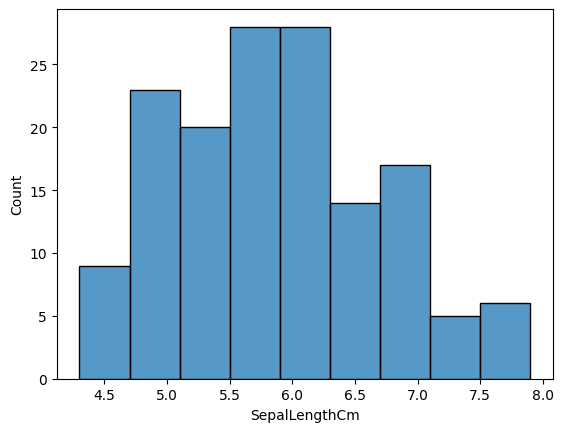

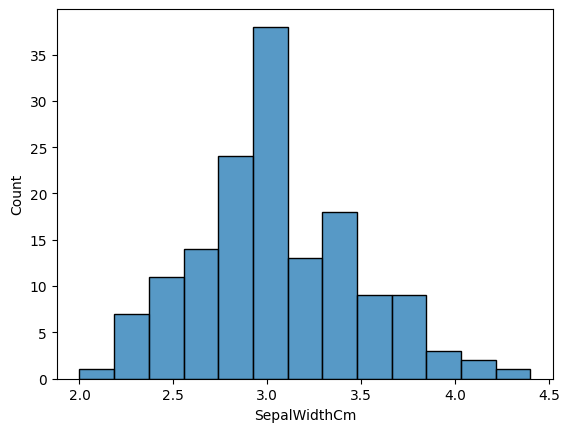

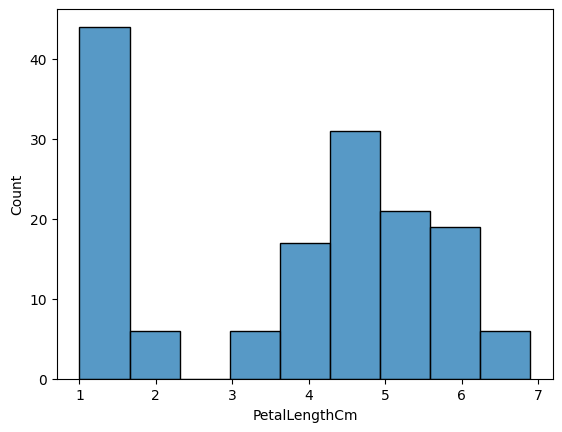

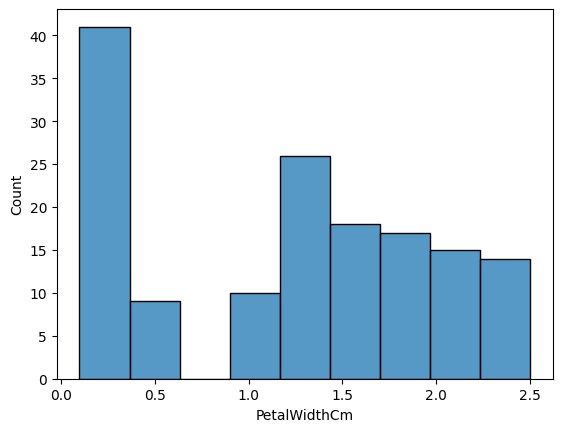

In [16]:
#histogram to understand the distribution
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()



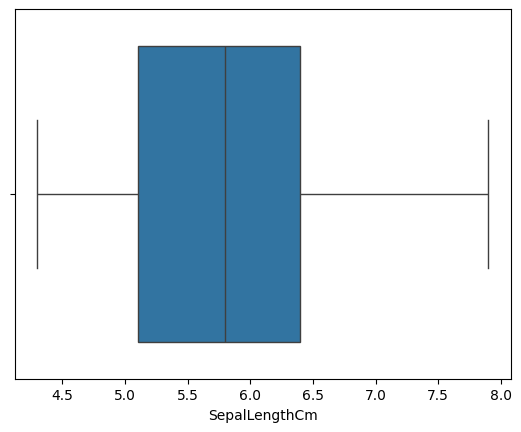

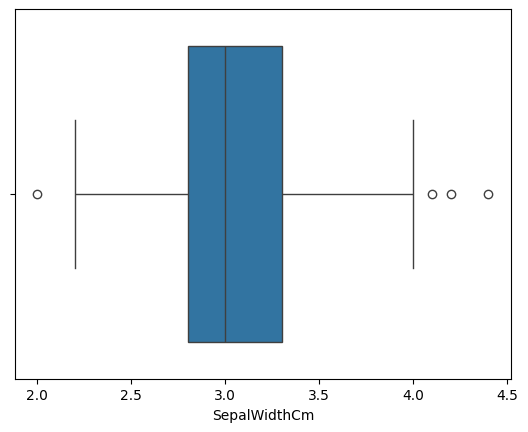

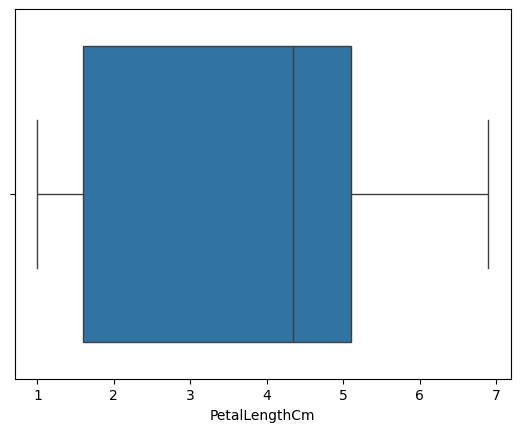

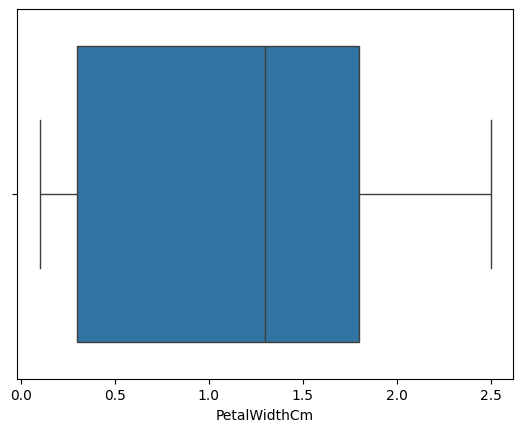

In [17]:
#boxplot to identify outliers
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()


In [18]:
df.select_dtypes(include="number").columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')

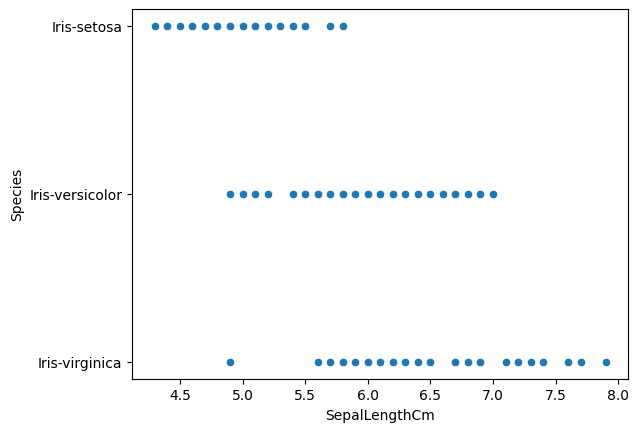

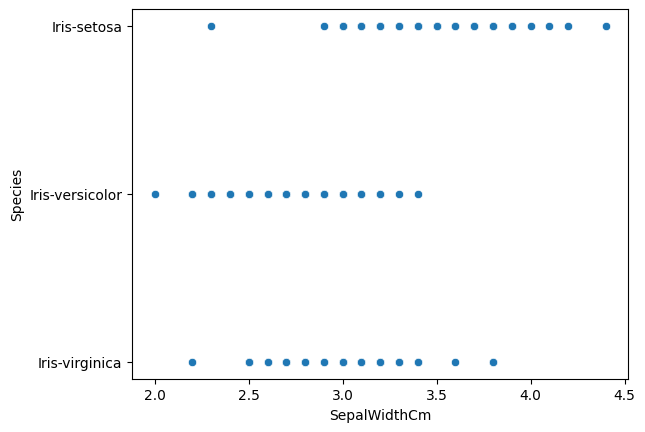

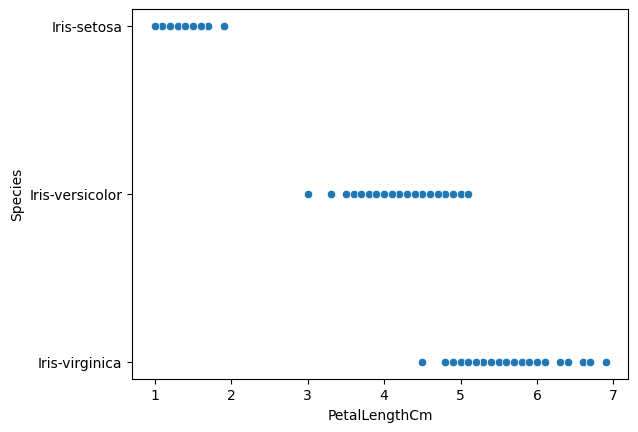

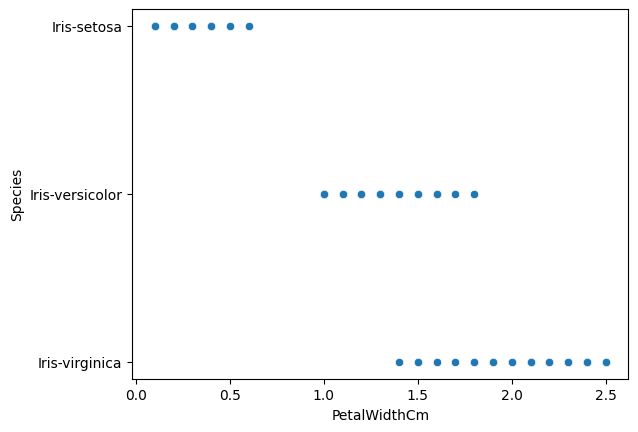

In [19]:
#scatter plot to understand the relationship
for i in ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']:
    sns.scatterplot(data=df,x=i,y='Species')
    plt.show()

In [20]:
#correlation with heat ap to interpret the relaton and mulicollinarity
s=df.select_dtypes(include="number").corr()

<Axes: >

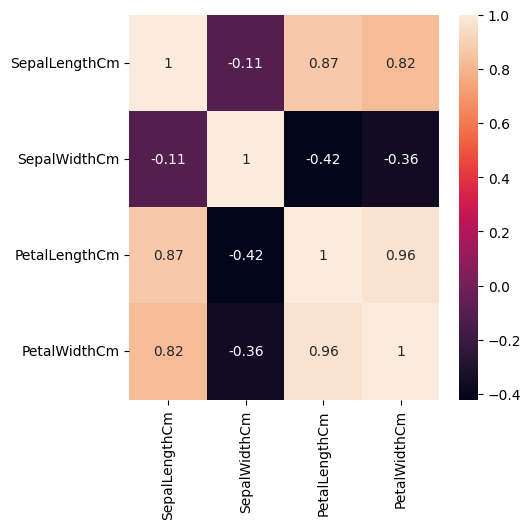

In [21]:
plt.figure(figsize=(5,5))
sns.heatmap(s,annot=True)

In [22]:
#missing values treatmeants
#like mean, median, mode or knniputer
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [24]:
for i in ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']:
    df[i].fillna(df[i].median())
    # in place we have to fill mode,mean means chnge median to mean or mode

In [25]:
from sklearn.impute import KNNImputer
impute=KNNImputer()

In [29]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='mean')

num_cols = df.select_dtypes(include='number').columns

df[num_cols] = impute.fit_transform(df[num_cols])
print(df[num_cols])

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]


In [30]:
#decide whether to do outliers treatment or not, if do how?
def wisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [34]:
wisker(df['SepalWidthCm'])

(np.float64(2.05), np.float64(4.05))

In [35]:
for i in ['SepalWidthCm']:
    lw,uw=wisker(df[i])
    df[i]=np.where(df[i]<lw,lw,df[i])
    df[i]=np.where(df[i]>uw,uw,df[i])

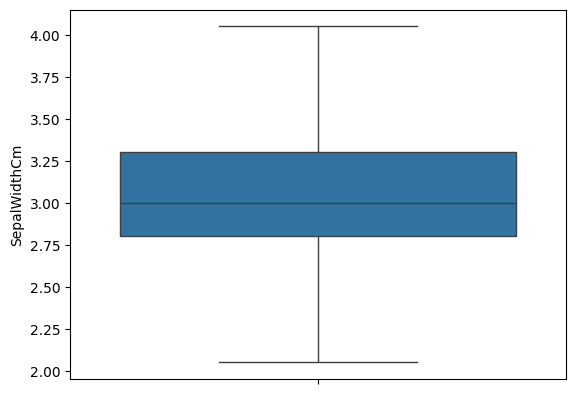

In [36]:
for i in ['SepalWidthCm']:
    sns.boxplot(df[i])
    plt.show()

In [37]:
#drop duplicates
df.drop_duplicates()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [38]:
#encoding data
dummy=pd.get_dummies(data=df,columns=['SepalLengthCm', 'SepalWidthCm'],drop_first=True)

In [39]:
dummy

,PetalLengthCm,PetalWidthCm,Species,SepalLengthCm_4.4,SepalLengthCm_4.5,SepalLengthCm_4.6,SepalLengthCm_4.7,SepalLengthCm_4.8,SepalLengthCm_4.9,SepalLengthCm_5.0,...,SepalWidthCm_3.2,SepalWidthCm_3.3,SepalWidthCm_3.4,SepalWidthCm_3.5,SepalWidthCm_3.6,SepalWidthCm_3.7,SepalWidthCm_3.8,SepalWidthCm_3.9,SepalWidthCm_4.0,SepalWidthCm_4.05
0,1.4,0.2,Iris-setosa,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,1.4,0.2,Iris-setosa,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,1.3,0.2,Iris-setosa,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,1.5,0.2,Iris-setosa,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.4,0.2,Iris-setosa,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,5.2,2.3,Iris-virginica,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
146,5.0,1.9,Iris-virginica,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
147,5.2,2.0,Iris-virginica,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148,5.4,2.3,Iris-virginica,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
